In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [4]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\_nonaromatic_2025_2783_CHOSi.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
1118,"1,3-Diisobutyrin, trimethylsilyl",C14H28O5Si,304,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)C(=O)OCC(COC(=O)C(C)C)O[Si](C)(C)C,CHOSi
1219,"Hentriacontane-10,14,16-trione, mono-TMS",C34H66O3Si,550,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCCCCCCCCCCC(=O)/C=C(/CCCC(=O)CCCCCCCCC)O[...,CHOSi
1226,"Eicosanoic acid, 2,3-bis[(trimethylsilyl)oxy]p...",C29H62O4Si2,530,55517-94-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCCCCCCCCCCCCCCC(=O)OCC(CO[Si](C)(C)C)O[Si...,CHOSi
1251,"1,2-Dioxetane, 3,4,4-trimethyl-3-[[(trimethyls...",C9H20O3Si,204,108536-14-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC1(C)OOC1(C)CO[Si](C)(C)C,CHOSi
1284,3-Ethyl(dimethyl)silyloxypentadecane,C19H42OSi,314,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCCCCCCCC(CC)CCO[SiH](C)C,CHOSi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180236,3-Dimethylsilyloxytetradecane,C16H36OSi,272,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCCCCCCC(CC)O[SiH](C)C,CHOSi
180237,3-Dimethylsilyloxypentadecane,C17H38OSi,286,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCCCCCCCC(CC)O[SiH](C)C,CHOSi
180238,1-Di(tert-butyl)silyloxydecane,C18H40OSi,300,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCCCCCO[SiH](C(C)(C)C)C(C)(C)C,CHOSi
180769,1-Diisopropylsilyloxy-10-undecene,C17H36OSi,284,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)[SiH](OCCCCCCCCCC=C)C(C)C,CHOSi


In [5]:
# Create DEEPCHEM dataset
# First check if there are SMILES with a dot '.'
# These cannot be FEATURIZED and must be removed from the dataset.

X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
se = []
dr = [] # all these compounds should be removed
c=0
for i in y:
  se.append(sf.encoder(i))  # contains all SELFIES
  if '.' in sf.encoder(i):  # check if there is a dot in the selfies
    dr.append(c)
  c=c+1
# remove compounds which will give an error when featurizing
a=0
for i in dr:
  ms = ms.drop([ms.index[i-a]])
  a=a+1
# create new DeepChem dataset
X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
ds = dc.data.DiskDataset.from_numpy(X,y)
ds

<DiskDataset X.shape: (np.int64(2783), np.int64(600)), y.shape: (np.int64(2783),), w.shape: (np.int64(2783),), task_names: [0]>

In [6]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[/C@H1]': 3,
 '[/C]': 4,
 '[/Si]': 5,
 '[=Branch1]': 6,
 '[=Branch2]': 7,
 '[=CH0]': 8,
 '[=CH2]': 9,
 '[=C]': 10,
 '[=N]': 11,
 '[=O]': 12,
 '[Branch1]': 13,
 '[Branch2]': 14,
 '[C@@H1]': 15,
 '[C@@]': 16,
 '[C@H1]': 17,
 '[C@]': 18,
 '[CH1]': 19,
 '[C]': 20,
 '[N]': 21,
 '[O]': 22,
 '[P]': 23,
 '[Ring1]': 24,
 '[Ring2]': 25,
 '[S]': 26,
 '[SiH1]': 27,
 '[SiH2]': 28,
 '[SiH3]': 29,
 '[Si]': 30,
 '[\\C@H1]': 31,
 '[\\C]': 32,
 '[\\Si]': 33,
 '[nop]': 34}

In [7]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

----------------------------

In [8]:
import deepchem as dc

seed = 42  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.8,
    frac_valid=0,
    frac_test=0.2,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 42
📦 Training set size: 2200
📦 Validation set size: 0
📦 Test set size: 583


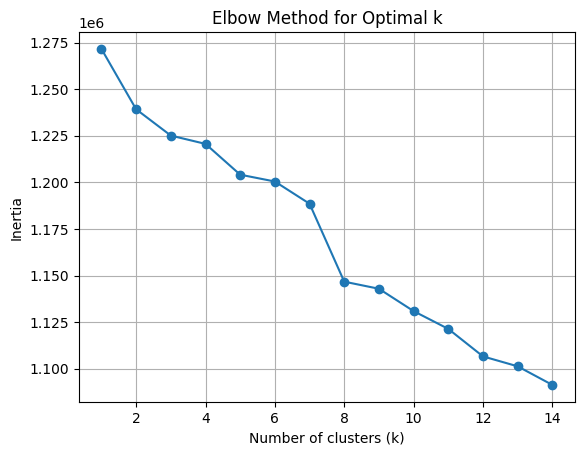

🔍 Elbow point detected at k = 8


In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [71]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=2,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new vers

In [72]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(2):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (1809, 600)
Cluster 1 shape: (391, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new vers

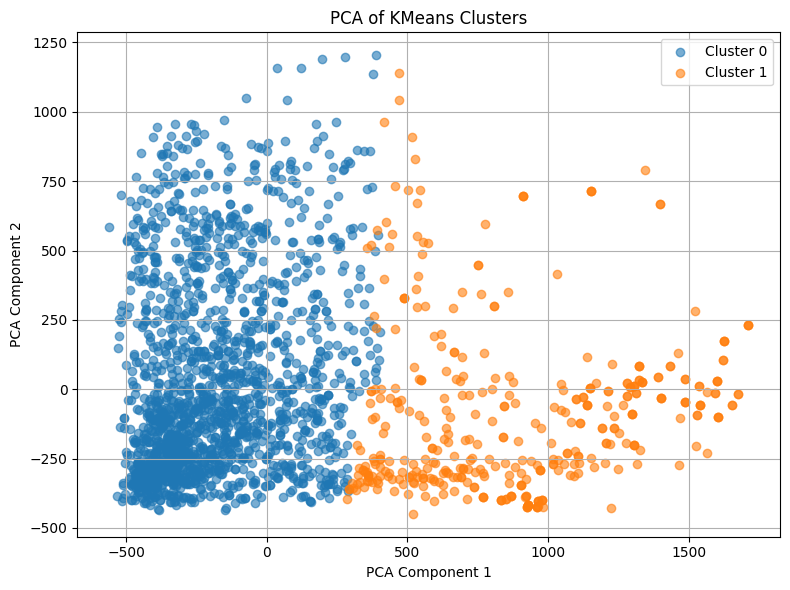

In [73]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [74]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [ ]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")

✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\

Cluster 0: size = 483, shape = (483, 600)
Cluster 1: size = 100, shape = (100, 600)


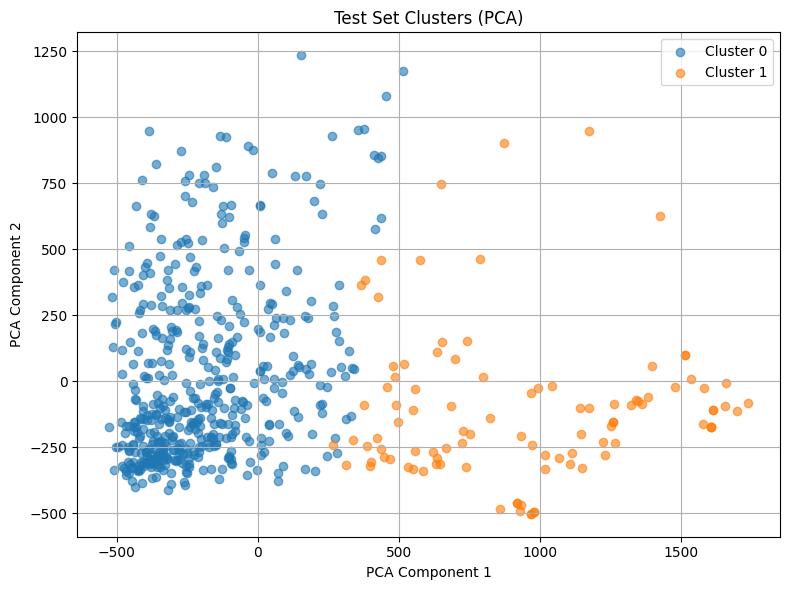

In [ ]:
import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(2):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.163061
Epoch 2/100 - Loss: 0.032680
Epoch 3/100 - Loss: 0.028144
Epoch 4/100 - Loss: 0.025822
Epoch 5/100 - Loss: 0.024301
Epoch 6/100 - Loss: 0.022860
Epoch 7/100 - Loss: 0.021930
Epoch 8/100 - Loss: 0.020853
Epoch 9/100 - Loss: 0.019732
Epoch 10/100 - Loss: 0.018506
Epoch 11/100 - Loss: 0.016620
Epoch 12/100 - Loss: 0.016413
Epoch 13/100 - Loss: 0.015617
Epoch 14/100 - Loss: 0.014676
Epoch 15/100 - Loss: 0.013851
Epoch 16/100 - Loss: 0.010622
Epoch 17/100 - Loss: 0.012177
Epoch 18/100 - Loss: 0.011331
Epoch 19/100 - Loss: 0.010736
Epoch 20/100 - Loss: 0.010052
Epoch 21/100 - Loss: 0.009446
Epoch 22/100 - Loss: 0.008839
Epoch 23/100 - Loss: 0.008398
Epoch 24/100 - Loss: 0.008049
Epoch 25/100 - Loss: 0.007584
Epoch 26/100 - Loss: 0.007110
Epoch 27/100 - Loss: 0.006831
Epoch 28/100 - Loss: 0.006394
Epoch 29/100 - Loss: 0.006069
Epoch 30/100 - Loss: 0.005727
Epoch 31/100 - Loss: 0.005473
Epoch 32/100 - Loss: 0.005117
Epoch 33/100 - Loss: 0.005062
Epoch 34/100 - Loss

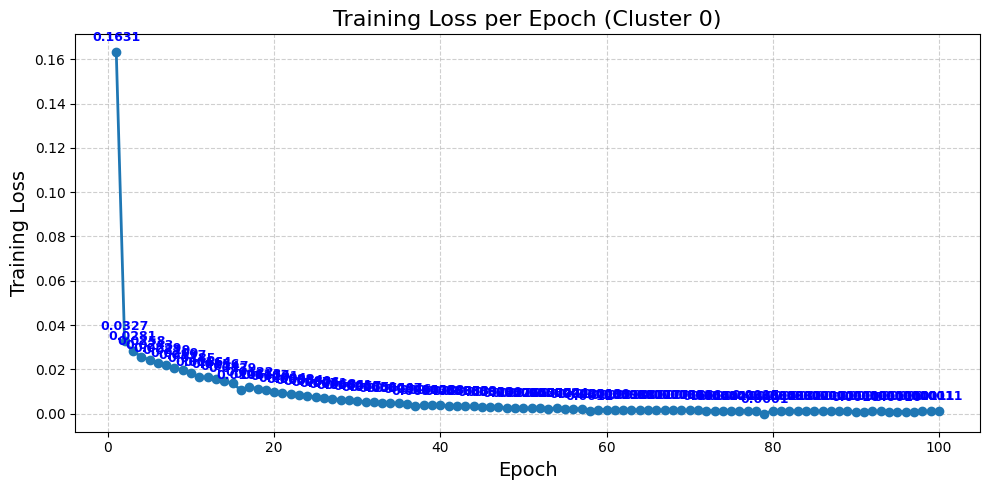

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\models_\model0000


In [77]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [78]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [79]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (483, 2730, 2)
Example prediction: [[1.0000000e+00 3.8473236e-15]
 [1.0000000e+00 3.0251951e-15]
 [1.0000000e+00 1.4450026e-14]
 ...
 [1.0000000e+00 8.5897807e-16]
 [1.0000000e+00 2.7421108e-15]
 [1.6460867e-13 1.0000000e+00]]


In [80]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [81]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [82]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CC(C)C(=O)OCC(COC(=O)C(C)C)O[Si](C)(C)C | True: CC(C)C(=O)OCC(COC(=O)C(C)C)O[Si](C)(C)C | Tanimoto: 1.000
[1] Pred: C(C)CCCCO[Si](C)(C)C | True: COCCCCCCCO[Si](C)(C)C | Tanimoto: 0.816
[2] Pred: C[Si](C)(C)OCCCCCCC | True: CCOC(=O)C(CCC=C(C)C)[Si](C)(C)C | Tanimoto: 0.097
[3] Pred: C1[Si](C)C1OCCCCCCO[Si](C)CCC | True: C[Si]1(CCCC1)OCCCCCCO[Si]2(C)CCCC2 | Tanimoto: 0.418
[4] Pred: C1[Si](C)CC(=O)CCCC1 | True: CCO[Si]1(OCC)OC=CC=C1 | Tanimoto: 0.046
[5] Pred: C[Si](C)(C)OCCOCCOCCOCCOCCOCCO | True: C[Si](C)(C)OCCOCCOCCOCCOCCOCCOCCO | Tanimoto: 1.000
[6] Pred: CC(C)(C)[Si](C)(C)OCCOCCOCCOCCOCCO | True: CC(C)(C)[Si](C)(C)OCCOCCOCCOCCO | Tanimoto: 1.000
[7] Pred: C[Si](C)(C)OCCOCCOCCOCCOCCOCCOCCOCCOCCO | True: C[Si](C)(C)OCCOCCOCCOCCOCCOCCOCCOCCOCCOCCO | Tanimoto: 1.000
[8] Pred: CCCCCC=CCCCOCCCCCCCCCCO[SiH1][SiH1]CC | True: CCCCCC=CCCCOCCCCCCCCO[SiH1](C)C | Tanimoto: 0.634
[9] Pred: CCCCCCCC | True: C[Si](C)(C)/C=C/C1(O)CC2CC1C=C2 | Tanimoto: 0.031
[10] Pred: CC(O)[SiH1](CCCCC)CC

[22:00:21] Explicit valence for atom # 7 Si, 7, is greater than permitted


[108] Pred: CCCCCC(C)C[Si]CCCCCC | True: C[Si](C)(CCCOCC1CO1)O[Si](C)(C)CCCOCC2CO2 | Tanimoto: 0.065
[109] Pred: C[Si]1(CCC1)OCCCC2(C)CCC2 | True: C[Si]1(CCC1)OCCCCO[Si]2(C)CCC2 | Tanimoto: 0.642
[110] Pred: COCCO[Si](C)(C)CC | True: COCCO[Si](C)(C)OCCOC | Tanimoto: 0.363
[111] Pred: CCCCCCCCCCCCCCCCCC[Si](C)(OCC)OCC | True: CCCCCCCCCCCC[Si](C)(OCC)OCC | Tanimoto: 1.000
[112] Pred: CC(C)(C)CCCCCCC(C)(C)CCC | True: CC(C)(CCCCCC(=O)O[Si](C)(C)C)O[Si](C)(C)C | Tanimoto: 0.141
[113] Pred: CC(C)(COC(C)CC)CC=CC | True: CCCC#CCC(CC)O[Si](C)(C)C | Tanimoto: 0.087
[114] Pred: CC(C)CCCCCCC(C)C | True: CCC(CC)CCC(CC)O[Si](C)(C)C | Tanimoto: 0.169
[115] Pred: C[Si](C)(C)OC1CCC(CC1)O[Si](C)(C)C | True: C[Si](C)(C)OC1CCC(CC1)O[Si](C)(C)C | Tanimoto: 1.000
[116] Pred: CCCCCCCCCCCC(=O)CC(C)CCC | True: C[C@H1](CCCC(C)(C)O[Si](C)(C)C)[C@H1]1CC[C@H1]2[C@@H1]3CC=C4C[C@@H1](CC[C@]4(C)[C@H1]3CC[C@]12C)O[Si](C)(C)C | Tanimoto: 0.093
[117] Pred: CC(C)(CC(C)CCC)CC | True: CCC(C)(C)O[Si](C)(C)C | Tanimoto: 0.10

Epoch 1/100 - Loss: 0.732299
Epoch 2/100 - Loss: 0.047528
Epoch 3/100 - Loss: 0.029730
Epoch 4/100 - Loss: 0.024116
Epoch 5/100 - Loss: 0.022322
Epoch 6/100 - Loss: 0.020689
Epoch 7/100 - Loss: 0.019204
Epoch 8/100 - Loss: 0.017995
Epoch 9/100 - Loss: 0.016746
Epoch 10/100 - Loss: 0.015800
Epoch 11/100 - Loss: 0.015000
Epoch 12/100 - Loss: 0.013994
Epoch 13/100 - Loss: 0.013326
Epoch 14/100 - Loss: 0.012627
Epoch 15/100 - Loss: 0.012088
Epoch 16/100 - Loss: 0.011339
Epoch 17/100 - Loss: 0.010695
Epoch 18/100 - Loss: 0.010160
Epoch 19/100 - Loss: 0.009742
Epoch 20/100 - Loss: 0.009057
Epoch 21/100 - Loss: 0.008681
Epoch 22/100 - Loss: 0.008208
Epoch 23/100 - Loss: 0.007628
Epoch 24/100 - Loss: 0.007409
Epoch 25/100 - Loss: 0.006904
Epoch 26/100 - Loss: 0.006488
Epoch 27/100 - Loss: 0.006141
Epoch 28/100 - Loss: 0.005689
Epoch 29/100 - Loss: 0.005605
Epoch 30/100 - Loss: 0.005143
Epoch 31/100 - Loss: 0.004846
Epoch 32/100 - Loss: 0.004510
Epoch 33/100 - Loss: 0.004332
Epoch 34/100 - Loss

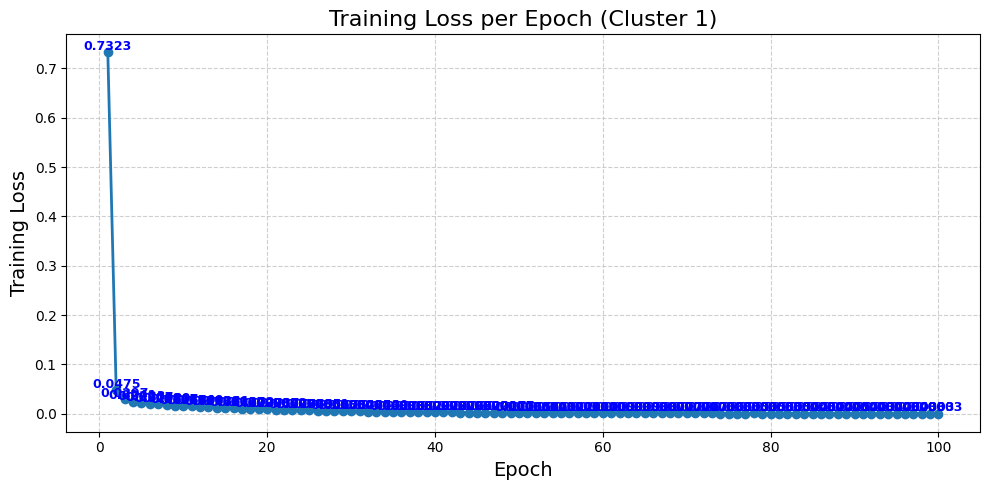

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model1111


In [83]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [84]:


import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (100, 2730, 2)
Example prediction: [[1.0000000e+00 3.4562214e-10]
 [1.0000000e+00 8.7919994e-10]
 [1.0000000e+00 1.3915759e-11]
 ...
 [1.0000000e+00 6.7300882e-10]
 [1.0000000e+00 7.4844930e-10]
 [8.0339324e-10 1.0000000e+00]]
[0] Pred: CCCCCCCCC(CCCC)O[Si]1(C)CCCCC1 | True: CCCCCCCCC(CCCC)O[Si]1(C)CCCCC1 | Tanimoto: 1.000
[1] Pred: CCCCCCCCCCC(CCC)O[Si]1(C)CCCCC1 | True: CCCCCCCCCCC(CCC)O[Si]1(C)CCCCC1 | Tanimoto: 1.000
[2] Pred: CCCCCCCCC(CCCCCC)O[Si]1(C)CCCCC1 | True: CCCCCCCCC(CCCCCC)O[Si]1(C)CCCCC1 | Tanimoto: 1.000
[3] Pred: CCCCCCCCC(CCCCC)O[SiH1](C)C | True: CCCCCCCCC(CCCCC)O[SiH1](C)C | Tanimoto: 1.000
[4] Pred: CCCCCCCCCCC(CCCC)O[SiH1](C)C | True: CCCCCCCCCCC(CCCC)O[SiH1](C)C | Tanimoto: 1.000
[5] Pred: CCCCCCCCC(CCCCCC)O[SiH1](C)C | True: CCCCCCCCC(CCCCCC)O[SiH1](C)C | Tanimoto: 1.000
[6] Pred: CCCCCCC(CCCCC)O[Si](C)(C)CC | True: CCCCCCC(CCCCC)O[Si](C)(C)CC | Tanimoto: 1.000
[7] Pred: CCCCCCCCCCCC(CC)CCCO[SiH1](C)C | True: CCCCCCCCCCCC(CC)CCCO[SiH1](C)C |

Epoch 1/100 - Loss: 1.105873
Epoch 2/100 - Loss: 0.052555
Epoch 3/100 - Loss: 0.045264
Epoch 4/100 - Loss: 0.036291
Epoch 5/100 - Loss: 0.025806
Epoch 6/100 - Loss: 0.021614
Epoch 7/100 - Loss: 0.019876
Epoch 8/100 - Loss: 0.018322
Epoch 9/100 - Loss: 0.017260
Epoch 10/100 - Loss: 0.016522
Epoch 11/100 - Loss: 0.015490
Epoch 12/100 - Loss: 0.014721
Epoch 13/100 - Loss: 0.013834
Epoch 14/100 - Loss: 0.013067
Epoch 15/100 - Loss: 0.012234
Epoch 16/100 - Loss: 0.011642
Epoch 17/100 - Loss: 0.011023
Epoch 18/100 - Loss: 0.010240
Epoch 19/100 - Loss: 0.009543
Epoch 20/100 - Loss: 0.009082
Epoch 21/100 - Loss: 0.008522
Epoch 22/100 - Loss: 0.007935
Epoch 23/100 - Loss: 0.007598
Epoch 24/100 - Loss: 0.007212
Epoch 25/100 - Loss: 0.006678
Epoch 26/100 - Loss: 0.006373
Epoch 27/100 - Loss: 0.005874
Epoch 28/100 - Loss: 0.005349
Epoch 29/100 - Loss: 0.005162
Epoch 30/100 - Loss: 0.004716
Epoch 31/100 - Loss: 0.004564
Epoch 32/100 - Loss: 0.004177
Epoch 33/100 - Loss: 0.004078
Epoch 34/100 - Loss

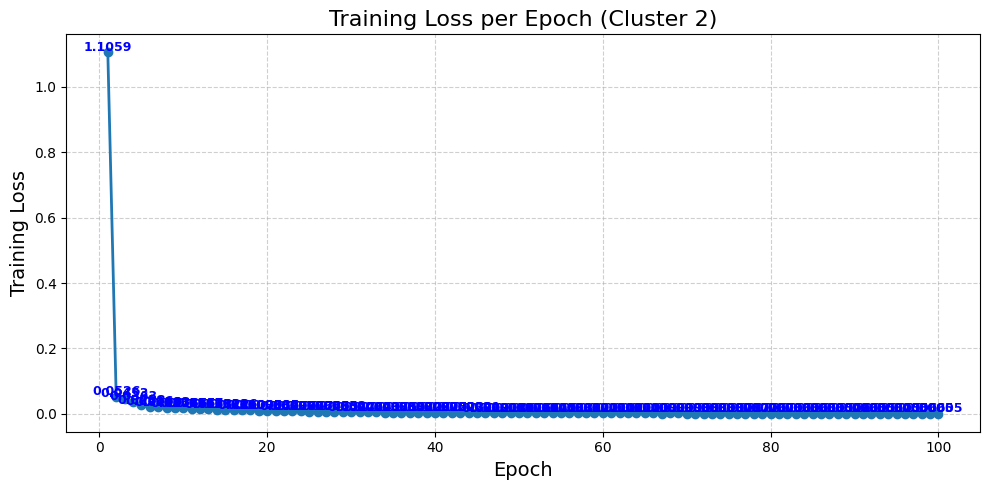

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model2222


In [57]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

# Ensure y is 2D
if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [ ]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_1
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])
evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (37, 2730, 2)
Example prediction: [[1.0000000e+00 2.7467828e-13]
 [1.0000000e+00 5.6619515e-11]
 [1.0000000e+00 4.0336533e-11]
 ...
 [1.0000000e+00 5.2294821e-11]
 [1.0000000e+00 7.0546291e-11]
 [1.2440029e-11 1.0000000e+00]]
[0] Pred: COC(=O)C1CC1(C)C[Si](C)CCC | True: COC(=O)C1CC1CC#C[Si](C)(C)C | Tanimoto: 0.354
[1] Pred: C[Si](C)(C)OCCOCCOCCOCCOCCOCCO | True: C[Si](C)(C)OCCOCCOCCOCCOCCO | Tanimoto: 1.000
[2] Pred: C[Si](C)(C)OCCOCCCOCCOCCOCO | True: C[Si](C)(C)OCCOCCOCCOCCO | Tanimoto: 0.691
[3] Pred: C[Si](C)(C)OCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCO | True: C[Si](C)(C)OCCOCCOCCOCCOCCOCCOCCOCCOCCOCCO | Tanimoto: 1.000
[4] Pred: COCCOCCOCO[Si]CCC | True: COCCOCCO[Si](C)(C)C | Tanimoto: 0.304
[5] Pred: COCCOCCOCCOCCOC[Si]COC[Si](C)(C)CCCCC | True: COCCOCCOCCOCCOCCOCCO[Si](C)(C)C | Tanimoto: 0.186
[6] Pred: COCCOCCOCCOCCOCCOC(O)CCOCCO[Si](C)(C)C | True: COCCOCCOCCOCCOCCOCCOCCO[Si](C)(C)C | Tanimoto: 0.562
[7] Pred: COCCCCCC[Si](C)(C)C | True: COC(=O)O[Si](C)(C)C | Tani

Epoch 1/100 - Loss: 0.793606
Epoch 2/100 - Loss: 0.078873
Epoch 3/100 - Loss: 0.053629
Epoch 4/100 - Loss: 0.042809
Epoch 5/100 - Loss: 0.040233
Epoch 6/100 - Loss: 0.037786
Epoch 7/100 - Loss: 0.035499
Epoch 8/100 - Loss: 0.033419
Epoch 9/100 - Loss: 0.031640
Epoch 10/100 - Loss: 0.030042
Epoch 11/100 - Loss: 0.028860
Epoch 12/100 - Loss: 0.027545
Epoch 13/100 - Loss: 0.026169
Epoch 14/100 - Loss: 0.025108
Epoch 15/100 - Loss: 0.023879
Epoch 16/100 - Loss: 0.022880
Epoch 17/100 - Loss: 0.021710
Epoch 18/100 - Loss: 0.020653
Epoch 19/100 - Loss: 0.019543
Epoch 20/100 - Loss: 0.018518
Epoch 21/100 - Loss: 0.017461
Epoch 22/100 - Loss: 0.016590
Epoch 23/100 - Loss: 0.015415
Epoch 24/100 - Loss: 0.014664
Epoch 25/100 - Loss: 0.013815
Epoch 26/100 - Loss: 0.013093
Epoch 27/100 - Loss: 0.012041
Epoch 28/100 - Loss: 0.011215
Epoch 29/100 - Loss: 0.010796
Epoch 30/100 - Loss: 0.010013
Epoch 31/100 - Loss: 0.009542
Epoch 32/100 - Loss: 0.009021
Epoch 33/100 - Loss: 0.008358
Epoch 34/100 - Loss

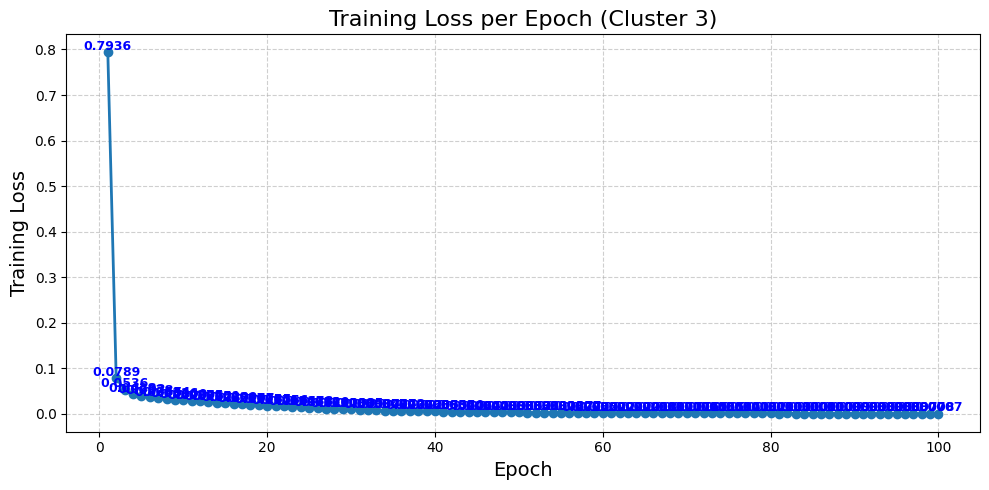

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model3333


In [59]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 3 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_3.pkl", "rb") as f:
    X_cluster3 = pickle.load(f)

cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_3_indices.npy")
y_cluster3 = train_dataset.y[cluster_3_indices]

# Ensure y is 2D
if len(y_cluster3.shape) == 1:
    y_cluster3 = y_cluster3.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_3 = dc.data.NumpyDataset(X=np.array(X_cluster3), y=np.array(y_cluster3))

# === Model config
n_tasks = train_dataset_3.y.shape[1]
n_features = train_dataset_3.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_3 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model3333"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_3.fit(train_dataset_3, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 3)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_3.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [60]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 3 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3.pkl", "rb") as f:
    X_test_cluster3 = pickle.load(f)

# === Load corresponding indices
test_cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster3 = test_dataset.y[test_cluster_3_indices]

if len(y_test_cluster3.shape) == 1:
    y_test_cluster3 = y_test_cluster3.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 3
test_dataset_3 = dc.data.NumpyDataset(X=np.array(X_test_cluster3), y=np.array(y_test_cluster3))

# === Predict using the trained model_3
predictions_3 = model_3.predict(test_dataset_3)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_3.shape)
print("Example prediction:", predictions_3[0])

# === Evaluate predictions (assuming evaluate_flat_predictions, itos, and sf are already defined)
evaluate_flat_predictions(predictions_3, test_dataset_3, itos, sf, cutoff=0.5)


✅ Prediction shape: (63, 2730, 2)
Example prediction: [[9.9999809e-01 1.8870995e-06]
 [1.0000000e+00 2.5451170e-09]
 [1.0000000e+00 5.2230806e-08]
 ...
 [1.0000000e+00 1.2786470e-10]
 [1.0000000e+00 3.8731569e-09]
 [7.6816971e-09 1.0000000e+00]]
[0] Pred: CCCCCCCCCOCC(C)C | True: CCOC(=O)C(CCC=C(C)C)[Si](C)(C)C | Tanimoto: 0.120
[1] Pred: CCCCCCCC(C)CO[Si]CC | True: C[Si](C)(C)/C=C/C1(O)CC2CC1C=C2 | Tanimoto: 0.110
[2] Pred: CCCCCCCCCCCCCCCCC[Si](C)C(C)C(C)C | True: CC(C)(C)OCCCCO[Si](C)(C)C | Tanimoto: 0.096
[3] Pred: CC(CCCC=CC(O)CC(=O)OCC[Si](C)(C)C)OC1CCCCO1 | True: CC(CCCC=CC(O)CC(=O)OCC[Si](C)(C)C)OC1CCCCO1 | Tanimoto: 1.000
[4] Pred: COC(=O)C1CC(=C)C(C1C(=O)OC)[Si](C)(C)C | True: COC(=O)C1CC(=C)C(C1C(=O)OC)[Si](C)(C)C | Tanimoto: 1.000
[5] Pred: CCC(/C=C/C(C)C1CCC2C3CC=C4CC(CCC4(C)C3CCC12C)O[Si](C)(C)C)C(C)C | True: CCC(/C=C/C(C)C1CCC2C3CC=C4CC(CCC4(C)C3CCC12C)O[Si](C)(C)C)C(C)C | Tanimoto: 1.000
[6] Pred: CCCCCCCCC(C)CCCOC(C)C | True: CC1(C)OCC(O1)C2OC3OC(C)(C)OC3C2O[Si](C)(C)C

Epoch 1/100 - Loss: 1.043249
Epoch 2/100 - Loss: 0.039665
Epoch 3/100 - Loss: 0.031861
Epoch 4/100 - Loss: 0.021326
Epoch 5/100 - Loss: 0.016993
Epoch 6/100 - Loss: 0.014960
Epoch 7/100 - Loss: 0.013737
Epoch 8/100 - Loss: 0.012752
Epoch 9/100 - Loss: 0.011901
Epoch 10/100 - Loss: 0.010853
Epoch 11/100 - Loss: 0.010040
Epoch 12/100 - Loss: 0.009255
Epoch 13/100 - Loss: 0.008598
Epoch 14/100 - Loss: 0.008003
Epoch 15/100 - Loss: 0.007513
Epoch 16/100 - Loss: 0.007050
Epoch 17/100 - Loss: 0.006514
Epoch 18/100 - Loss: 0.006238
Epoch 19/100 - Loss: 0.005690
Epoch 20/100 - Loss: 0.005424
Epoch 21/100 - Loss: 0.005066
Epoch 22/100 - Loss: 0.004867
Epoch 23/100 - Loss: 0.004513
Epoch 24/100 - Loss: 0.004397
Epoch 25/100 - Loss: 0.004347
Epoch 26/100 - Loss: 0.004129
Epoch 27/100 - Loss: 0.003649
Epoch 28/100 - Loss: 0.003490
Epoch 29/100 - Loss: 0.003305
Epoch 30/100 - Loss: 0.003072
Epoch 31/100 - Loss: 0.003061
Epoch 32/100 - Loss: 0.002759
Epoch 33/100 - Loss: 0.002678
Epoch 34/100 - Loss

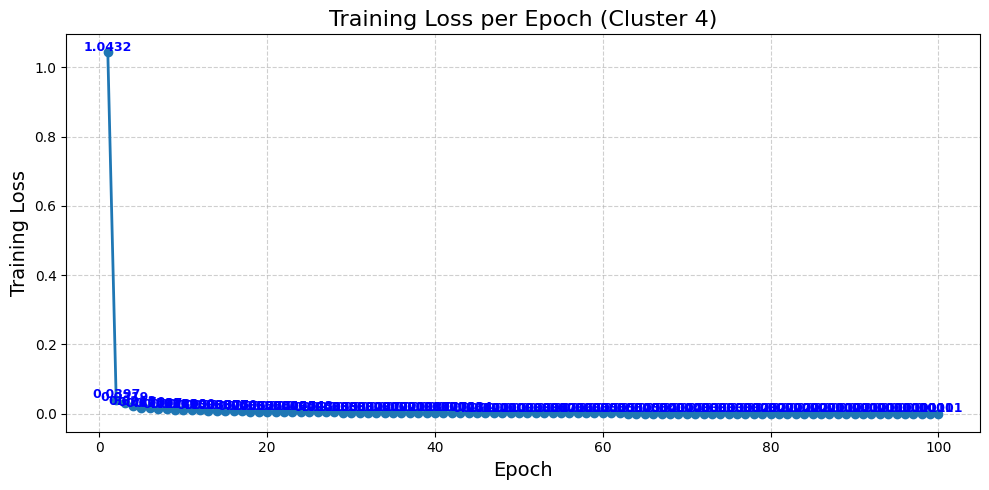

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model4444


In [61]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 4 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_4.pkl", "rb") as f:
    X_cluster4 = pickle.load(f)

cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_4_indices.npy")
y_cluster4 = train_dataset.y[cluster_4_indices]

# Ensure y is 2D
if len(y_cluster4.shape) == 1:
    y_cluster4 = y_cluster4.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_4 = dc.data.NumpyDataset(X=np.array(X_cluster4), y=np.array(y_cluster4))

# === Model config
n_tasks = train_dataset_4.y.shape[1]
n_features = train_dataset_4.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_4 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model4444"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_4.fit(train_dataset_4, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 4)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_4.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [62]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 4 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4.pkl", "rb") as f:
    X_test_cluster4 = pickle.load(f)

# === Load corresponding indices
test_cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster4 = test_dataset.y[test_cluster_4_indices]

if len(y_test_cluster4.shape) == 1:
    y_test_cluster4 = y_test_cluster4.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 4
test_dataset_4 = dc.data.NumpyDataset(X=np.array(X_test_cluster4), y=np.array(y_test_cluster4))

# === Predict using the trained model_4
predictions_4 = model_4.predict(test_dataset_4)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_4.shape)
print("Example prediction:", predictions_4[0])

# === Evaluate predictions (assuming evaluate_flat_predictions, itos, and sf are already defined)
evaluate_flat_predictions(predictions_4, test_dataset_4, itos, sf, cutoff=0.5)


✅ Prediction shape: (49, 2730, 2)
Example prediction: [[9.9999988e-01 1.1403328e-07]
 [1.0000000e+00 5.5071791e-08]
 [1.0000000e+00 1.1245208e-08]
 ...
 [1.0000000e+00 7.1643362e-09]
 [9.9999988e-01 7.3296498e-08]
 [5.6576499e-09 1.0000000e+00]]
[0] Pred: CCCCCCCCCCCC(C)O[Si]1(C)CCCCC1 | True: CCCCCCCCCCCC(C)O[Si]1(C)CCCCC1 | Tanimoto: 1.000
[1] Pred: CCCCCCCCC(CCCCC)O[Si]1(C)CCCCC1 | True: CCCCCCCCC(CCCCC)O[Si]1(C)CCCCC1 | Tanimoto: 1.000
[2] Pred: CCCCCCCCC(CCCCC)O[SiH1](C)C | True: CCCCCCCCC(CCCCC)O[SiH1](C)C | Tanimoto: 1.000
[3] Pred: CCCCCCCCCCC(CCCC)O[SiH1](C)C | True: CCCCCCCCCCC(CCCC)O[SiH1](C)C | Tanimoto: 1.000
[4] Pred: CCCCCCCCCCCCCCCO[SiH1](C(C)(C)C)C(C)(C)C | True: CCCCCCCCCCCCCCCO[SiH1](C(C)(C)C)C(C)(C)C | Tanimoto: 1.000
[5] Pred: CCCCCCCCCC(C)O[Si](C)(C)CC | True: CCCCCCCCCC(C)O[Si](C)(C)CC | Tanimoto: 1.000
[6] Pred: CCCCCCCCCC(CCC)O[SiH1](C)C | True: CCCCCCCCCC(CCC)O[SiH1](C)C | Tanimoto: 1.000
[7] Pred: CCCCCCCCCCC(CCC)O[SiH1](C)C | True: CCCCCCCCCCC(CCC)O[SiH1](C)

Epoch 1/100 - Loss: 0.274325
Epoch 2/100 - Loss: 0.039166
Epoch 3/100 - Loss: 0.034031
Epoch 4/100 - Loss: 0.030670
Epoch 5/100 - Loss: 0.027820
Epoch 6/100 - Loss: 0.025696
Epoch 7/100 - Loss: 0.024062
Epoch 8/100 - Loss: 0.022621
Epoch 9/100 - Loss: 0.021317
Epoch 10/100 - Loss: 0.019863
Epoch 11/100 - Loss: 0.018773
Epoch 12/100 - Loss: 0.017022
Epoch 13/100 - Loss: 0.016398
Epoch 14/100 - Loss: 0.015181
Epoch 15/100 - Loss: 0.014095
Epoch 16/100 - Loss: 0.012994
Epoch 17/100 - Loss: 0.012221
Epoch 18/100 - Loss: 0.011345
Epoch 19/100 - Loss: 0.010787
Epoch 20/100 - Loss: 0.010077
Epoch 21/100 - Loss: 0.009327
Epoch 22/100 - Loss: 0.008829
Epoch 23/100 - Loss: 0.007764
Epoch 24/100 - Loss: 0.007512
Epoch 25/100 - Loss: 0.007139
Epoch 26/100 - Loss: 0.006641
Epoch 27/100 - Loss: 0.006388
Epoch 28/100 - Loss: 0.005901
Epoch 29/100 - Loss: 0.005422
Epoch 30/100 - Loss: 0.005250
Epoch 31/100 - Loss: 0.005030
Epoch 32/100 - Loss: 0.004722
Epoch 33/100 - Loss: 0.004414
Epoch 34/100 - Loss

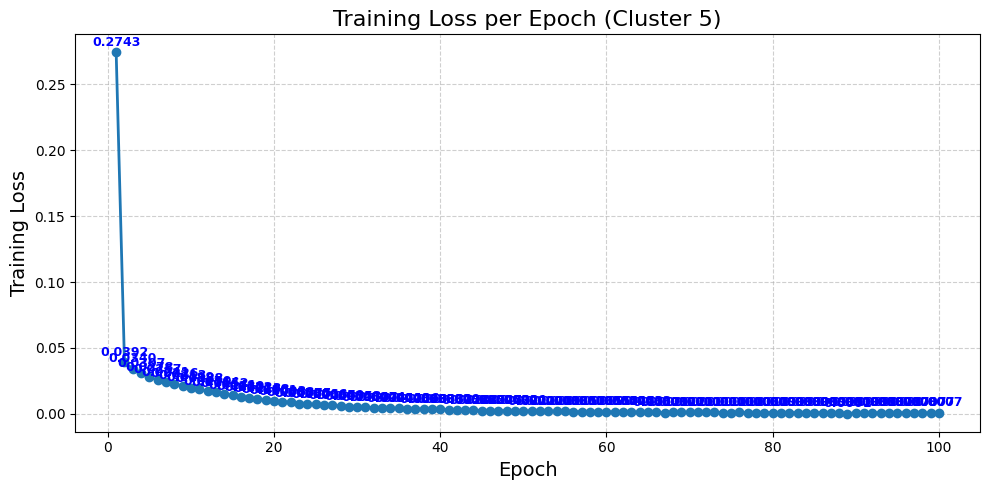

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model5555


In [63]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 5 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_5.pkl", "rb") as f:
    X_cluster5 = pickle.load(f)

cluster_5_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_5_indices.npy")
y_cluster5 = train_dataset.y[cluster_5_indices]

# Ensure y is 2D
if len(y_cluster5.shape) == 1:
    y_cluster5 = y_cluster5.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_5 = dc.data.NumpyDataset(X=np.array(X_cluster5), y=np.array(y_cluster5))

# === Model config
n_tasks = train_dataset_5.y.shape[1]
n_features = train_dataset_5.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_5 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model5555"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_5.fit(train_dataset_5, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 5)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_5.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [64]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 5 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_5.pkl", "rb") as f:
    X_test_cluster5 = pickle.load(f)

# === Load corresponding indices
test_cluster_5_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_5_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster5 = test_dataset.y[test_cluster_5_indices]

if len(y_test_cluster5.shape) == 1:
    y_test_cluster5 = y_test_cluster5.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 5
test_dataset_5 = dc.data.NumpyDataset(X=np.array(X_test_cluster5), y=np.array(y_test_cluster5))

# === Predict using the trained model_5
predictions_5 = model_5.predict(test_dataset_5)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_5.shape)
print("Example prediction:", predictions_5[0])

# === Evaluate predictions (assuming evaluate_flat_predictions, itos, and sf are already defined)
evaluate_flat_predictions(predictions_5, test_dataset_5, itos, sf, cutoff=0.5)


✅ Prediction shape: (237, 2730, 2)
Example prediction: [[1.0000000e+00 3.9220971e-08]
 [1.0000000e+00 1.2448236e-08]
 [9.9999988e-01 8.0808128e-08]
 ...
 [1.0000000e+00 3.1877270e-10]
 [1.0000000e+00 5.3640131e-11]
 [1.1062508e-08 1.0000000e+00]]
[0] Pred: CO[Si](OC)(OC)C[SiH2][Si](=O)(O)OC | True: CO[Si](OC)(OC)[SiH1]([Si](OC)(OC)OC)[Si](OC)(OC)OC | Tanimoto: 0.142
[1] Pred: CO[Si](OC)(OC)C(O[SiH3])([Si](OC)(OC)O)C(OO)C | True: CO[Si](OC)(OC)[Si](OC)(OC)[Si](OC)(OC)OC | Tanimoto: 0.087
[2] Pred: CCCCO[Si]O[Si](COCCC)CS(OCOC)CC(OCCC)C=CCCC=C | True: CCCCO[Si](OCCCC)(OCCCC)O[Si](OCCCC)(OCCCC)C=C | Tanimoto: 0.163
[3] Pred: C1CCCO[Si]1CCCOS[Si]CCCC(C)C | True: CC(C)(C)OO[Si](C)(C)C | Tanimoto: 0.098
[4] Pred: CC1CCC(C(C)C)C(C1)O[Si](C)(OC2CC(C)CCC2C(C)C)OC3CC(C)CCC3C(C)C | True: CC1CCC(C(C)C)C(C1)O[Si](C)(OC2CC(C)CCC2C(C)C)OC3CC(C)CCC3C(C)C | Tanimoto: 1.000
[5] Pred: COC1C(CO[Si](C)(C)C)OC(O[Si](C)(C)C)C(OC)C1OC | True: COC1C(CO[Si](C)(C)C)OC(O[Si](C)(C)C)C(OC)C1OC | Tanimoto: 1.000
[6]

Epoch 1/100 - Loss: 0.811325
Epoch 2/100 - Loss: 0.050062
Epoch 3/100 - Loss: 0.037601
Epoch 4/100 - Loss: 0.026385
Epoch 5/100 - Loss: 0.021894
Epoch 6/100 - Loss: 0.020380
Epoch 7/100 - Loss: 0.019543
Epoch 8/100 - Loss: 0.018534
Epoch 9/100 - Loss: 0.017453
Epoch 10/100 - Loss: 0.016610
Epoch 11/100 - Loss: 0.015805
Epoch 12/100 - Loss: 0.014934
Epoch 13/100 - Loss: 0.014297
Epoch 14/100 - Loss: 0.013799
Epoch 15/100 - Loss: 0.012919
Epoch 16/100 - Loss: 0.012197
Epoch 17/100 - Loss: 0.011705
Epoch 18/100 - Loss: 0.010994
Epoch 19/100 - Loss: 0.010495
Epoch 20/100 - Loss: 0.009938
Epoch 21/100 - Loss: 0.009423
Epoch 22/100 - Loss: 0.008776
Epoch 23/100 - Loss: 0.008484
Epoch 24/100 - Loss: 0.007959
Epoch 25/100 - Loss: 0.007521
Epoch 26/100 - Loss: 0.007192
Epoch 27/100 - Loss: 0.006776
Epoch 28/100 - Loss: 0.006279
Epoch 29/100 - Loss: 0.005974
Epoch 30/100 - Loss: 0.005628
Epoch 31/100 - Loss: 0.005286
Epoch 32/100 - Loss: 0.005055
Epoch 33/100 - Loss: 0.004655
Epoch 34/100 - Loss

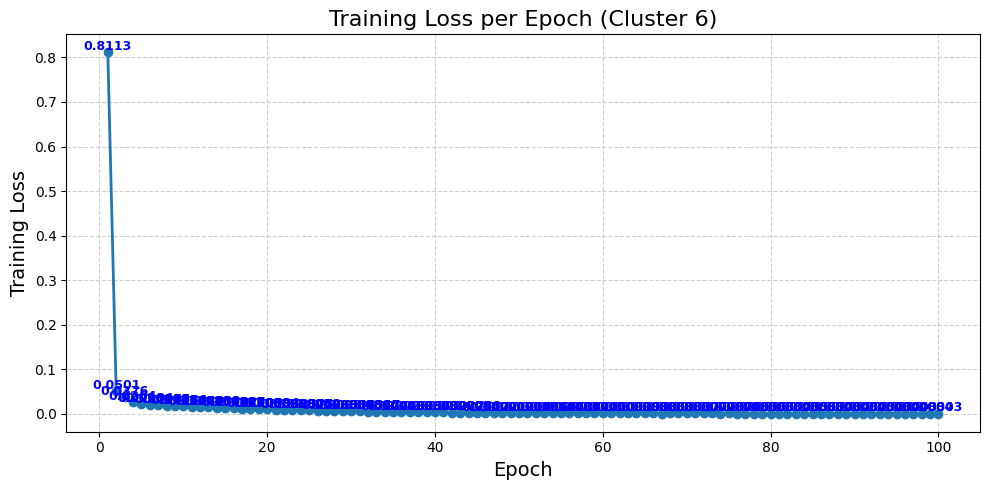

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model6666


In [65]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 6 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_6.pkl", "rb") as f:
    X_cluster6 = pickle.load(f)

cluster_6_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_6_indices.npy")
y_cluster6 = train_dataset.y[cluster_6_indices]

# Ensure y is 2D
if len(y_cluster6.shape) == 1:
    y_cluster6 = y_cluster6.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_6 = dc.data.NumpyDataset(X=np.array(X_cluster6), y=np.array(y_cluster6))

# === Model config
n_tasks = train_dataset_6.y.shape[1]
n_features = train_dataset_6.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_6 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with seed 123\models_\model6666"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_6.fit(train_dataset_6, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 6)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_6.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [66]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 6 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_6.pkl", "rb") as f:
    X_test_cluster6 = pickle.load(f)

# === Load corresponding indices
test_cluster_6_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_2783_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_6_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster6 = test_dataset.y[test_cluster_6_indices]

if len(y_test_cluster6.shape) == 1:
    y_test_cluster6 = y_test_cluster6.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 6
test_dataset_6 = dc.data.NumpyDataset(X=np.array(X_test_cluster6), y=np.array(y_test_cluster6))

# === Predict using the trained model_6
predictions_6 = model_6.predict(test_dataset_6)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_6.shape)
print("Example prediction:", predictions_6[0])

# === Evaluate predictions (assuming evaluate_flat_predictions, itos, and sf are already defined)
evaluate_flat_predictions(predictions_6, test_dataset_6, itos, sf, cutoff=0.5)


✅ Prediction shape: (62, 2730, 2)
Example prediction: [[1.0000000e+00 3.2126934e-09]
 [1.0000000e+00 3.6358749e-11]
 [1.0000000e+00 1.6118358e-10]
 ...
 [1.0000000e+00 1.8611366e-11]
 [1.0000000e+00 1.8143325e-09]
 [3.3727195e-11 1.0000000e+00]]
[0] Pred: CC(C)[SiH1](O)CCC(C)CC(C)C | True: CC(C)CCO[SiH1](C(C)C)C(C)C | Tanimoto: 0.233
[1] Pred: CCCCO[SiH1](C(C)C)C(C)C | True: CC(C)CO[SiH1](C(C)C)C(C)C | Tanimoto: 0.807
[2] Pred: CC(C)[SiH1](OCCCC)CC(C)C | True: CCCCCO[SiH1](C(C)C)C(C)C | Tanimoto: 0.654
[3] Pred: C[Si]CCCCC | True: CO[Si]1(C)CCCC1 | Tanimoto: 0.228
[4] Pred: CCCC(=O)O[Si](C)(C)C=C | True: CCCC(=O)O[Si](C)(C)C=C | Tanimoto: 1.000
[5] Pred: CCC(=O)O[Si](C)(C)C=C | True: CCC(=O)O[Si](C)(C)C=C | Tanimoto: 1.000
[6] Pred: CC1CCCC1(C)O[SiH2]C=C | True: CC1CCCC1(C)O[SiH2]C=C | Tanimoto: 1.000
[7] Pred: CC1CCCCC1(C)O[SiH2]=C | True: CCC1CCCCC1O[Si](C)(C)C=C | Tanimoto: 0.420
[8] Pred: CC(C)(C)CC | True: CC(C)(C)CO[Si](C)(C)C=C | Tanimoto: 0.100
[9] Pred: CC1CCC(C(C)C)C(C1)OC(OC

In [175]:
import pandas as pd

# Load your original DataFrame
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\_nonaromatic_2025_1491_CHNOS.pkl")

# Shuffle the rows with a fixed seed
ms = ms.sample(frac=1, random_state=42).reset_index(drop=True)

# Now 'ms' is shuffled in a reproducible way
print(ms.head())


                                                Name        Form   Mw  \
0  Acetamide, N-cyclohexyl-2-(1,1-dioxotetrahydro...  C12H21NO3S  259   
1     l-Methionine, N-allyloxycarbonyl-, ethyl ester  C11H19NO4S  261   
2  2-t-Butyl-4-methylene-3-(methylthio)methyloxaz...  C10H17NO2S  215   
3         3-Methyl-4-thio-5,5-diethylbarbituric acid  C9H14N2O2S  214   
4        Pyrrol-2,5(3H,4H)-dione, 1-methylsulphonyl-    C5H7NO4S  177   

          Cas  mz1  mz2  mz3  mz4  mz5  mz6  ...  mz594  mz595  mz596  mz597  \
0         NaN    0    0    0    0    0    0  ...      0      0      0      0   
1         NaN    0    0    0    0    0    0  ...      0      0      0      0   
2  86046-41-5    0    0    0    0    0    0  ...      0      0      0      0   
3         NaN    0    0    0    0    0    0  ...      0      0      0      0   
4  25417-46-3    0    0    0    0    0    0  ...      0      0      0      0   

   mz598  mz599  mz600  Filter_Form                            SMILES  \
0      

In [176]:
# Make a dictionary of all 'SELFIES' parts in the dataset
# Create DEEPCHEM dataset
# First check if there are SMILES with a dot '.'
# These cannot be FEATURIZED and must be removed from the dataset.

X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
se = []
dr = [] # all these compounds should be removed
c=0
for i in y:
  se.append(sf.encoder(i))  # contains all SELFIES
  if '.' in sf.encoder(i):  # check if there is a dot in the selfies
    dr.append(c)
  c=c+1
# remove compounds which will give an error when featurizing
a=0
for i in dr:
  ms = ms.drop([ms.index[i-a]])
  a=a+1
# create new DeepChem dataset
X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
ds = dc.data.DiskDataset.from_numpy(X,y)
ds
dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [177]:
def split_with_index_splitter(dataset, frac_train=0.8, frac_valid=0, frac_test=0.2):
    """
    Splits a DeepChem dataset deterministically using IndexSplitter:
    - First 80% for training
    - Next 10% for validation
    - Last 10% for testing

    Parameters:
    - dataset (dc.data.Dataset): Input dataset
    - frac_train (float): Fraction for training (default 0.8)
    - frac_valid (float): Fraction for validation (default 0.1)
    - frac_test (float): Fraction for testing (default 0.1)

    Returns:
    - train_dataset, valid_dataset, test_dataset (dc.data.Dataset)
    """
    from deepchem.splits import IndexSplitter

    splitter = IndexSplitter()
    train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
        dataset=dataset,
        frac_train=frac_train,
        frac_valid=frac_valid,
        frac_test=frac_test
    )

    print(f"✅ IndexSplitter split completed:")
    print(f"  Train size: {len(train_dataset)}")
    print(f"  Valid size: {len(valid_dataset)}")
    print(f"  Test size:  {len(test_dataset)}")

    return train_dataset, valid_dataset, test_dataset


In [178]:
train_dataset, valid_dataset, test_dataset = split_with_index_splitter(dataset)


✅ IndexSplitter split completed:
  Train size: 1192
  Valid size: 0
  Test size:  299


In [179]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=2,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files



In [180]:
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitti

In [181]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset"
clusters = {}

for i in range(2):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")


Cluster 0 shape: (776, 600)
Cluster 1 shape: (416, 600)


In [183]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitti

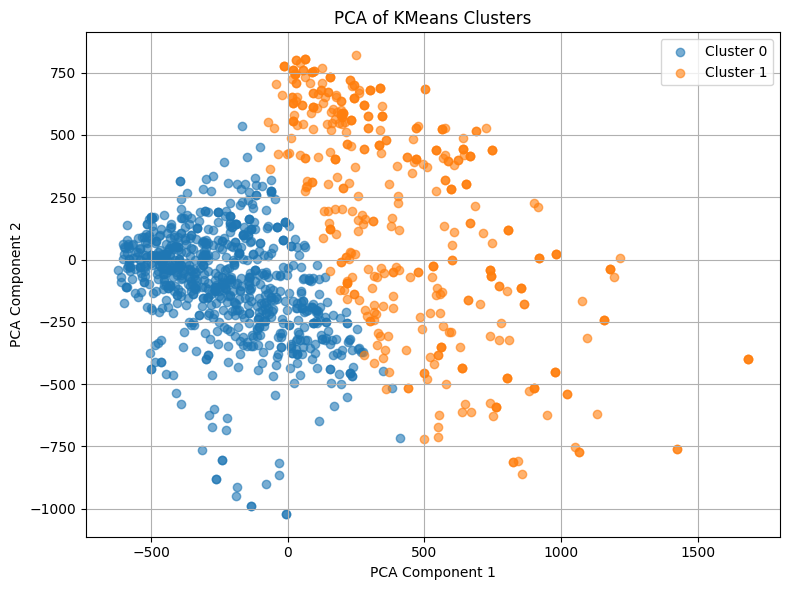

In [184]:
# Train KMeans and get labels
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [ ]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)


In [185]:

import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels


In [186]:
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset", dataset_label="test")


✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset\cluster_1_indices.npy


In [187]:
import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(2):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


Cluster 0: size = 172, shape = (172, 600)
Cluster 1: size = 127, shape = (127, 600)


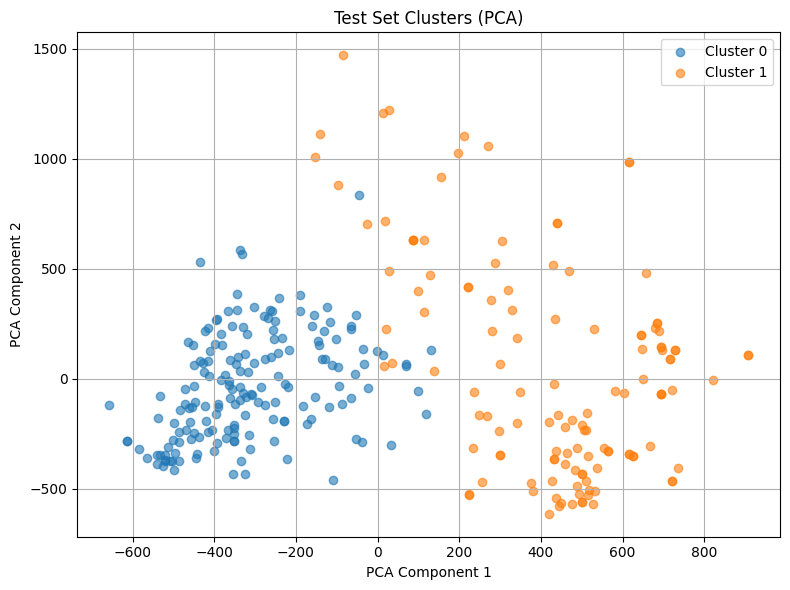

In [188]:
plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")



Epoch 1/100 - Loss: 0.296866
Epoch 2/100 - Loss: 0.030756
Epoch 3/100 - Loss: 0.027420
Epoch 4/100 - Loss: 0.025253
Epoch 5/100 - Loss: 0.023435
Epoch 6/100 - Loss: 0.021877
Epoch 7/100 - Loss: 0.020492
Epoch 8/100 - Loss: 0.019186
Epoch 9/100 - Loss: 0.018150
Epoch 10/100 - Loss: 0.017115
Epoch 11/100 - Loss: 0.016110
Epoch 12/100 - Loss: 0.015146
Epoch 13/100 - Loss: 0.013811
Epoch 14/100 - Loss: 0.013078
Epoch 15/100 - Loss: 0.012086
Epoch 16/100 - Loss: 0.011299
Epoch 17/100 - Loss: 0.010515
Epoch 18/100 - Loss: 0.009605
Epoch 19/100 - Loss: 0.008899
Epoch 20/100 - Loss: 0.008088
Epoch 21/100 - Loss: 0.007526
Epoch 22/100 - Loss: 0.006935
Epoch 23/100 - Loss: 0.006355
Epoch 24/100 - Loss: 0.006035
Epoch 25/100 - Loss: 0.005383
Epoch 26/100 - Loss: 0.004974
Epoch 27/100 - Loss: 0.004635
Epoch 28/100 - Loss: 0.004323
Epoch 29/100 - Loss: 0.004045
Epoch 30/100 - Loss: 0.003695
Epoch 31/100 - Loss: 0.003500
Epoch 32/100 - Loss: 0.003448
Epoch 33/100 - Loss: 0.003052
Epoch 34/100 - Loss

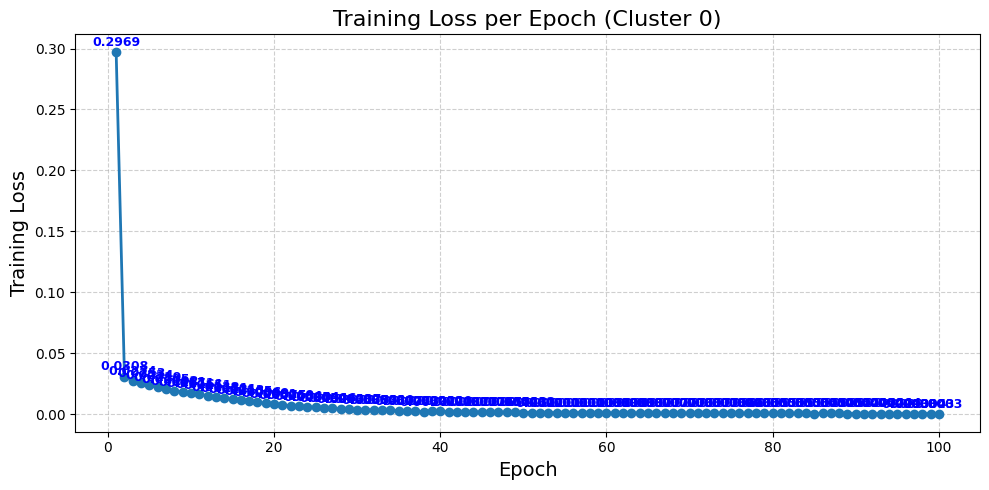

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\models_\model000


In [189]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\models_\model000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [190]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)

# === Wrap as DeepChem NumpyDataset
import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))


# Step 1: Create DeepChem dataset for test cluster 0
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

# Step 2: Predict using the trained model_0
predictions_0 = model_0.predict(test_dataset_0)

# Step 3: Inspect prediction shape and type
print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (172, 3456, 2)
Example prediction: [[1.0000000e+00 1.2757371e-12]
 [1.0000000e+00 2.1168843e-10]
 [1.0000000e+00 2.4341765e-11]
 ...
 [1.0000000e+00 3.6230890e-11]
 [1.0000000e+00 5.1070406e-13]
 [5.7494990e-12 1.0000000e+00]]


In [191]:
# Create a dictionairy (itos) to transfer the hot-encoding array into a array of SELFIES and SMILES

itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos

{0: '[#Branch1]',
 1: '[#Branch2]',
 2: '[#C]',
 3: '[#N]',
 4: '[/-Ring1]',
 5: '[/C]',
 6: '[/N+1]',
 7: '[/N]',
 8: '[/O]',
 9: '[=Branch1]',
 10: '[=Branch2]',
 11: '[=CH0]',
 12: '[=C]',
 13: '[=N+1]',
 14: '[=N-1]',
 15: '[=N]',
 16: '[=O]',
 17: '[=Ring1]',
 18: '[=SH0]',
 19: '[=S]',
 20: '[Branch1]',
 21: '[Branch2]',
 22: '[C-1]',
 23: '[C@@H1]',
 24: '[C@@]',
 25: '[C@H1]',
 26: '[C@]',
 27: '[CH0]',
 28: '[CH1]',
 29: '[CH2]',
 30: '[C]',
 31: '[N+1]',
 32: '[NH1+1]',
 33: '[NH2+1]',
 34: '[NH3+1]',
 35: '[N]',
 36: '[O-1]',
 37: '[O]',
 38: '[P]',
 39: '[Ring1]',
 40: '[Ring2]',
 41: '[SH0]',
 42: '[S]',
 43: '[\\-Ring1]',
 44: '[\\C]',
 45: '[\\N]',
 46: '[\\O]',
 47: '[nop]'}

In [192]:

from rdkit import Chem, DataStructs
import numpy as np

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        # Ground truth SELFIES (from flat one-hot in y)
        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [193]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CC(C)COC(=O)N(CCSSCCN)C(=O)OCC(C)C | True: CC(C)COC(=O)N(CCSSCCN)C(=O)OCC(C)C | Tanimoto: 1.000
[1] Pred: CCCCC(CNCC=SCC)C(=O)CC | True: CC([N+1]([O-1])=O)[SH0](=O)(=O)N1CCOCC1 | Tanimoto: 0.084
[2] Pred: COC1=NC23CCC4C5CCC(O)C5(C)CC(=O)C4(S1)C2(C)CCC(=O)C3 | True: COC1=NC23CCC4C5CCC(O)C5(C)CC(=O)C4(S1)C2(CO)CCC(=O)C3 | Tanimoto: 0.912
[3] Pred: CCCCCCCCCCCCCC=C=CC | True: CC1SC2(C3CC4CC(C3)CC2C4)C5C1C(=O)N(C)C5=O | Tanimoto: 0.045
[4] Pred: COC(=O)CCCCC=C | True: O=C1CSC2=NCCCN12 | Tanimoto: 0.068
[5] Pred: CCCCOC(=O)[C@H1](CCSC)NC(=O)OCC | True: CCCOC(=O)N[C@@H1](CCSC)C(=O)OCCC | Tanimoto: 0.973
[6] Pred: C1=CCCCCCC1N | True: CC1(C)CC(CC(C)(C)N1)N2CCC(=O)NC2=S | Tanimoto: 0.095
[7] Pred: CN(C)C(=S)SC1CCCC1=O | True: CN(C)C(=S)SC1CCCC1=O | Tanimoto: 1.000
[8] Pred: COCOCC(CC)CC=O | True: CN1C=C[N+1]23OC(=C(C)C2=O)S[C-1]13 | Tanimoto: 0.050
[9] Pred: CCCC1CC(C)CC2CC2N1N | True: CCCC(C)C1(CC=C)C(=O)NC(=S)NC1=O | Tanimoto: 0.181
[10] Pred: CC1(C)SCNC1C(O)=O | True: CC1(C)SCNC1C

Epoch 1/100 - Loss: 0.509920
Epoch 2/100 - Loss: 0.045719
Epoch 3/100 - Loss: 0.029006
Epoch 4/100 - Loss: 0.025425
Epoch 5/100 - Loss: 0.023538
Epoch 6/100 - Loss: 0.021744
Epoch 7/100 - Loss: 0.020125
Epoch 8/100 - Loss: 0.018776
Epoch 9/100 - Loss: 0.017496
Epoch 10/100 - Loss: 0.016409
Epoch 11/100 - Loss: 0.015488
Epoch 12/100 - Loss: 0.014339
Epoch 13/100 - Loss: 0.013605
Epoch 14/100 - Loss: 0.012502
Epoch 15/100 - Loss: 0.011699
Epoch 16/100 - Loss: 0.010719
Epoch 17/100 - Loss: 0.010014
Epoch 18/100 - Loss: 0.009421
Epoch 19/100 - Loss: 0.008695
Epoch 20/100 - Loss: 0.007960
Epoch 21/100 - Loss: 0.007281
Epoch 22/100 - Loss: 0.006701
Epoch 23/100 - Loss: 0.006190
Epoch 24/100 - Loss: 0.005719
Epoch 25/100 - Loss: 0.005145
Epoch 26/100 - Loss: 0.004828
Epoch 27/100 - Loss: 0.004465
Epoch 28/100 - Loss: 0.003991
Epoch 29/100 - Loss: 0.003659
Epoch 30/100 - Loss: 0.003451
Epoch 31/100 - Loss: 0.003044
Epoch 32/100 - Loss: 0.002924
Epoch 33/100 - Loss: 0.002815
Epoch 34/100 - Loss

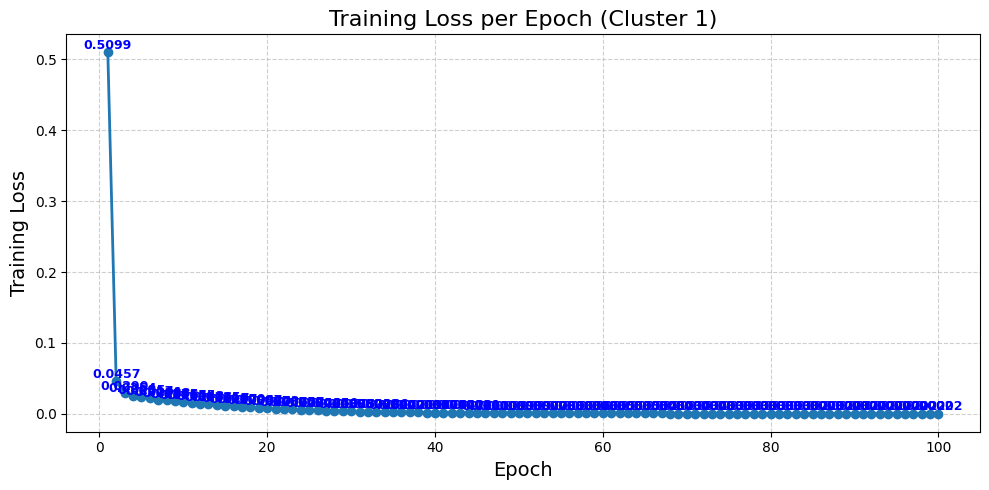

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\models_\model111


In [194]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\models_\model111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [ ]:


import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1491_CHNOS\Splitting  with  index\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])


✅ Prediction shape: (127, 3456, 2)
Example prediction: [[1.00000000e+00 2.29380642e-13]
 [1.00000000e+00 1.11486875e-10]
 [1.00000000e+00 1.77037010e-10]
 ...
 [1.00000000e+00 1.74336760e-11]
 [1.00000000e+00 6.75882628e-10]
 [8.45241573e-07 9.99999166e-01]]


In [196]:
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


[0] Pred: CCCCCCOCCCCCNCCCCOCCCCCCC | True: CCCCCCCCCCCCCCCCOC(=O)[C@H1](CCSC)NC(=O)OCC(C)(C)C | Tanimoto: 0.154
[1] Pred: CC1CC(C)(C)NC(=O)S1 | True: CC1CC(C)(C)NC(=O)S1 | Tanimoto: 1.000
[2] Pred: CC(=O)O[C@H1]1[C@@H1](O[C@@H1]([C@@H1](OC(C)=O)[C@@H1]1OC(C)=O)C(N)=O)N=C=S | True: CC(=O)O[C@H1]1[C@@H1](O[C@@H1]([C@@H1](OC(C)=O)[C@@H1]1OC(C)=O)C(N)=O)N=C=S | Tanimoto: 1.000
[3] Pred: CC(C)OCCCCCCCCOCCCCCC | True: CC(=O)OC1C2CC3C(OC(C)=O)C(CC1N3C=O)S2 | Tanimoto: 0.072
[4] Pred: CCCCN1C(=S)NCC(C)C1(C)O | True: CCCCN1C(=S)NCC(C)C1(C)O | Tanimoto: 1.000
[5] Pred: CC1CC(C)(C)NC(=S)O1 | True: CC1CC(C)(C)NC(=S)O1 | Tanimoto: 1.000
[6] Pred: CCCCC(N)SC(C)=O | True: CC(=O)NC(N)=S | Tanimoto: 0.071
[7] Pred: CC(=O)O[C@H1]1[C@@H1](O[C@@H1]([C@@H1](OC(C)=O)[C@@H1]1OC(C)=O)C(N)=O)N=C=S | True: CC(=O)O[C@H1]1[C@@H1](O[C@@H1]([C@@H1](OC(C)=O)[C@@H1]1OC(C)=O)C(N)=O)N=C=S | Tanimoto: 1.000
[8] Pred: NC(=N)SCC(O)=O | True: NC(=N)SCC(O)=O | Tanimoto: 1.000
[9] Pred: CC(C)(CCO)SC[C@H1](N)C(O)=O | True: C